In [1]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  result.append([displayInitJson, sim_result])


{k:2000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:3000000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:0,cof:0,threshold_velocity:1e-4}


恢复系数 k=2e3 的峰值时间和高度：
  时间: 1.8763553407532798 s, 高度: 4.000001221504022 m
  时间: 3.753710681506449 s, 高度: 4.000002443008066 m
恢复系数 k=2e5 的峰值时间和高度：
  时间: 1.8120358889055135 s, 高度: 4.000004929162559 m
  时间: 3.625071777810916 s, 高度: 4.000009858325195 m
恢复系数 k=3e6 的峰值时间和高度：
  时间: 1.8078145376438544 s, 高度: 3.9997737832315954 m
  时间: 3.614629075287598 s, 高度: 3.999547566463253 m
恢复系数 k=2e8 的峰值时间和高度：
  时间: 1.8062221552210163 s, 高度: 3.9931095164752257 m
  时间: 3.6094443104541996 s, 高度: 3.9862266637164288 m


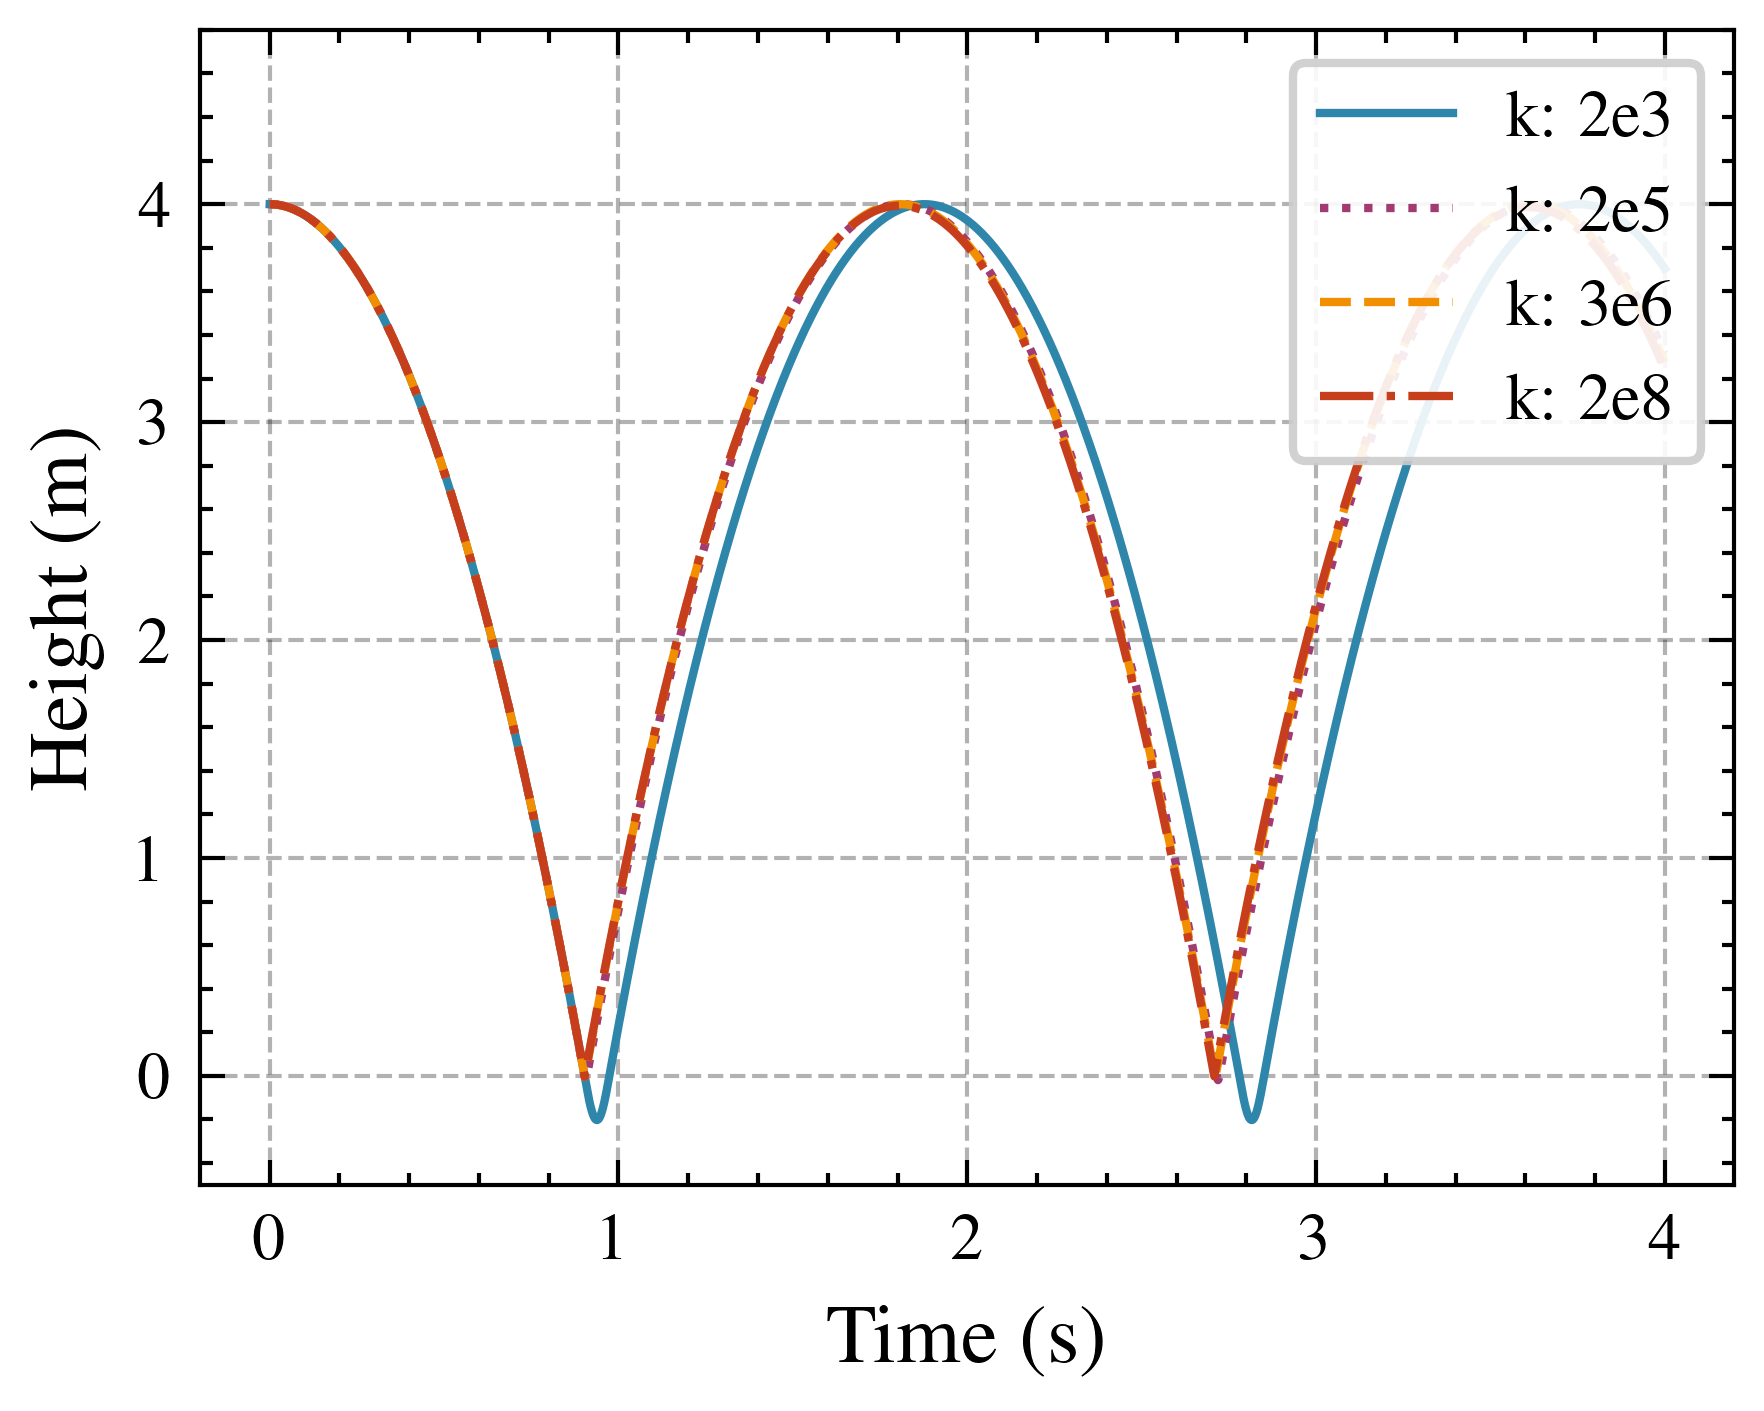

In [2]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0)
    upperBound = sire.binarySearch(timeIndices, 10)
    
    for j in range(lowerBound, upperBound):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      # print(partpq[j][1][2])
      y.append(partpq[j][1][2]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i % 4])
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(y)
    peak_times = np.array(x)[peaks]
    peak_heights = np.array(y)[peaks]

    print(f"恢复系数 k={simple_sci_format(parameters[i][0])} 的峰值时间和高度：")
    for t, h in zip(peak_times, peak_heights):
        print(f"  时间: {t} s, 高度: {h} m")

  # plt.legend(loc="best", fontsize=8)
  plt.legend(framealpha=0.9, loc="upper right")
  plt.ylim(top=4.8, bottom=-0.5)
  plt.ylabel(r'Height (m)', fontsize=10)
  plt.xlabel(r'Time (s)', fontsize=10)
  # plt.title('Bouncing ball by proposed method')
  plt.grid(True, alpha=0.3)
  # plt.tight_layout()
  plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf", dpi=600, bbox_inches='tight')
  plt.show()

902 907
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, N

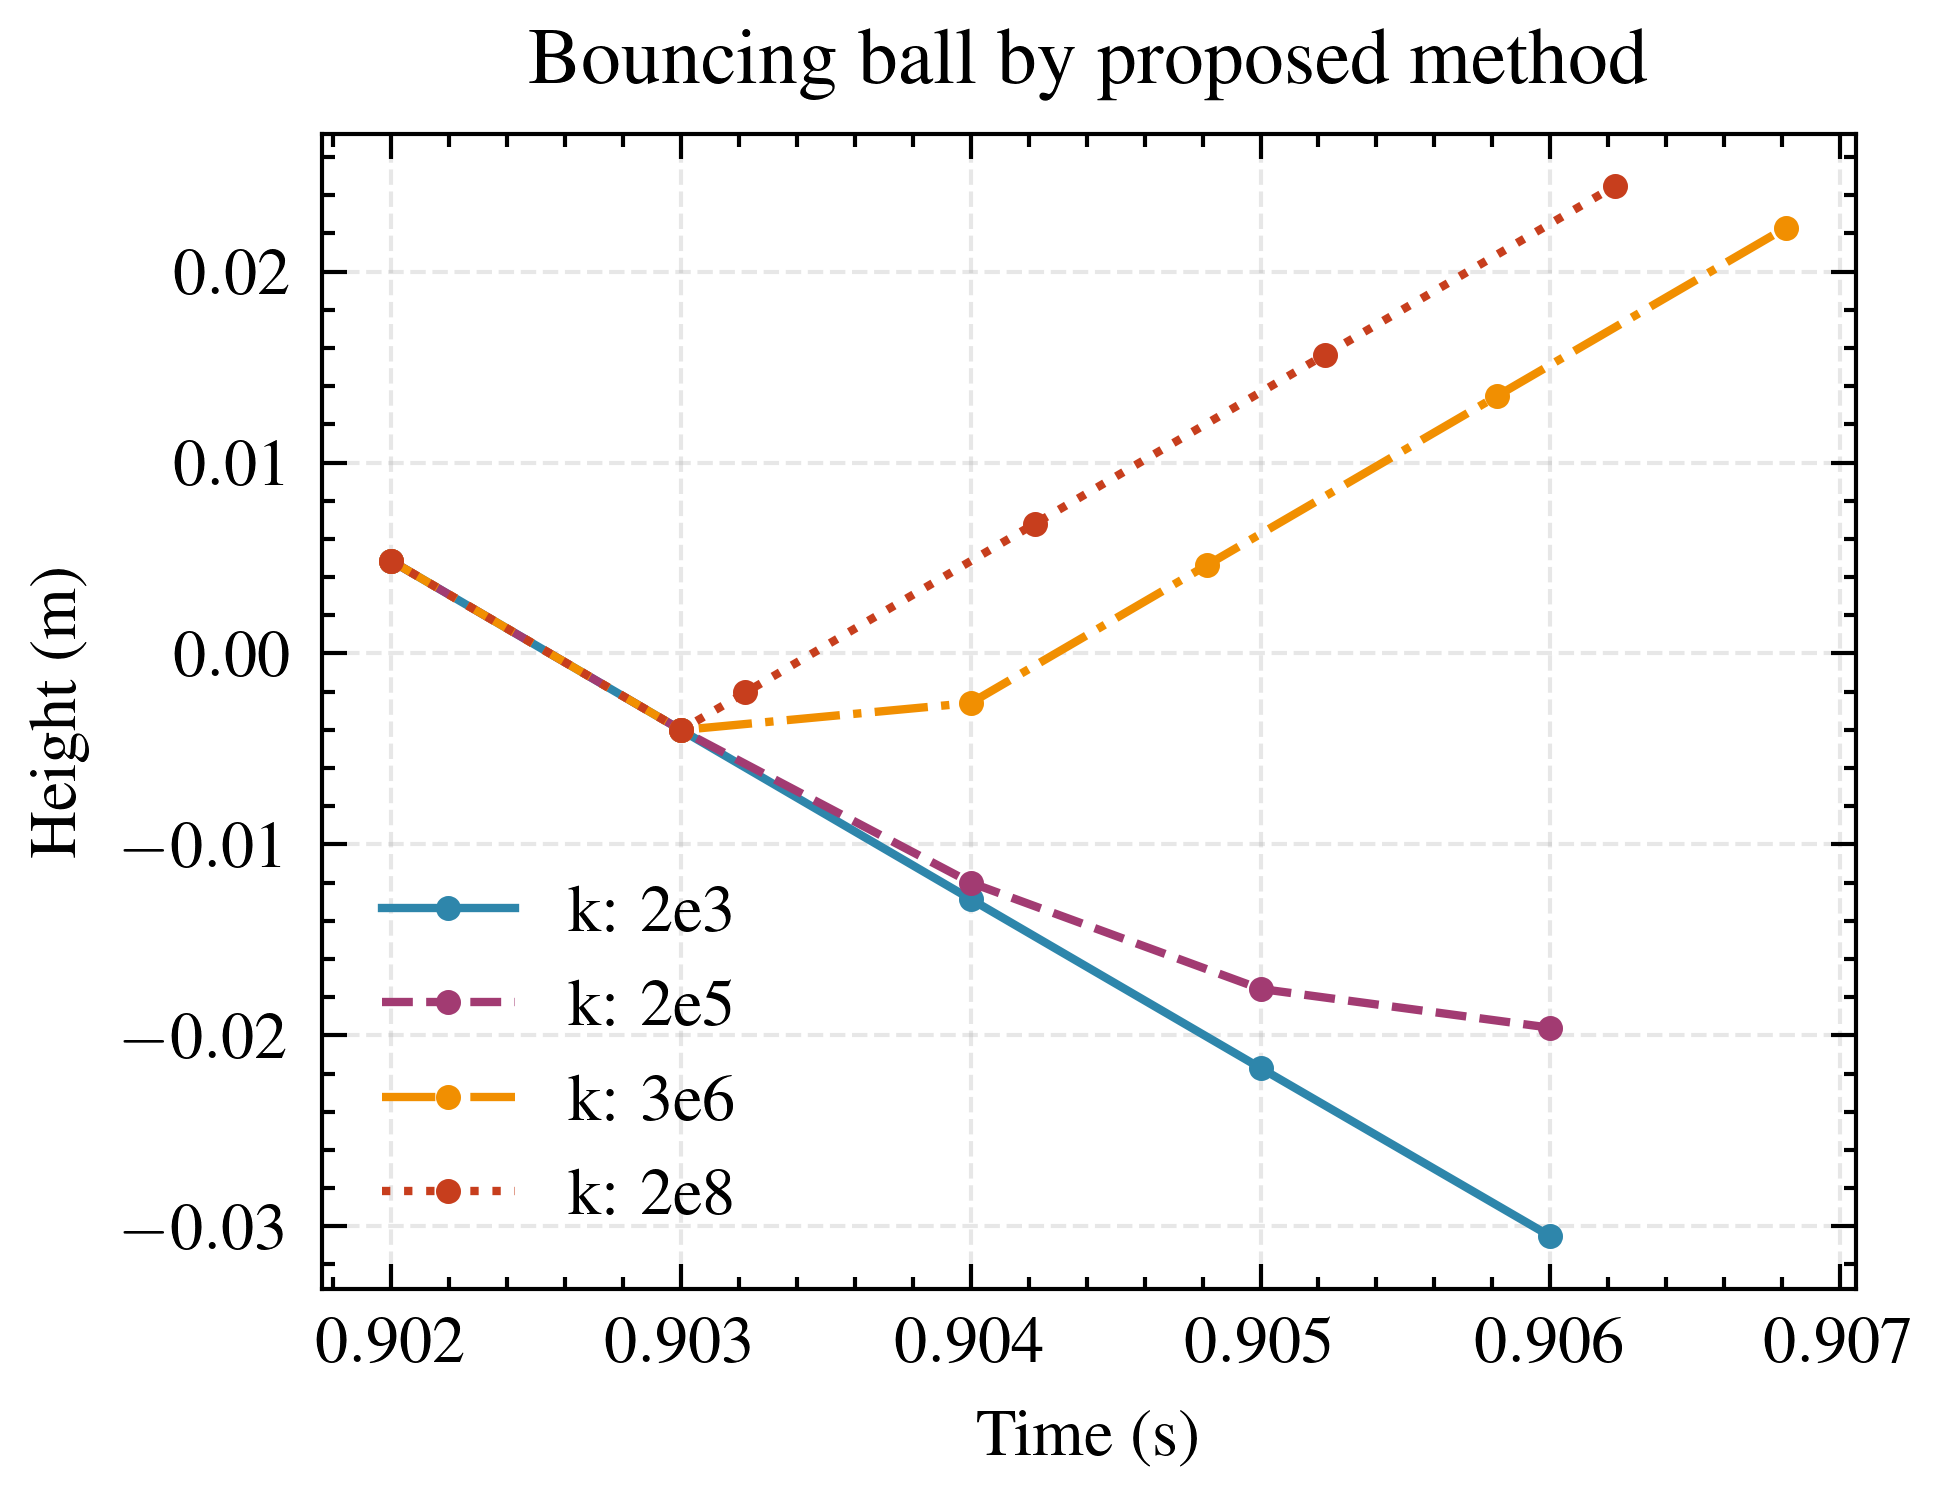

In [3]:
with plt.style.context(['science','ieee']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.906)
    print(lowerBound, upperBound + 1)
    print(contactInfo)
    for j in range(lowerBound, upperBound + 1):
      print(j, timeIndices[j], dts[j], partpq[j][1], partvs[j][1], partas[j][1], contactInfo[j])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)')
  plt.xlabel(r'Time (s)')
  plt.title('Bouncing ball by proposed method')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

902 907
902 907
902 908
902 908


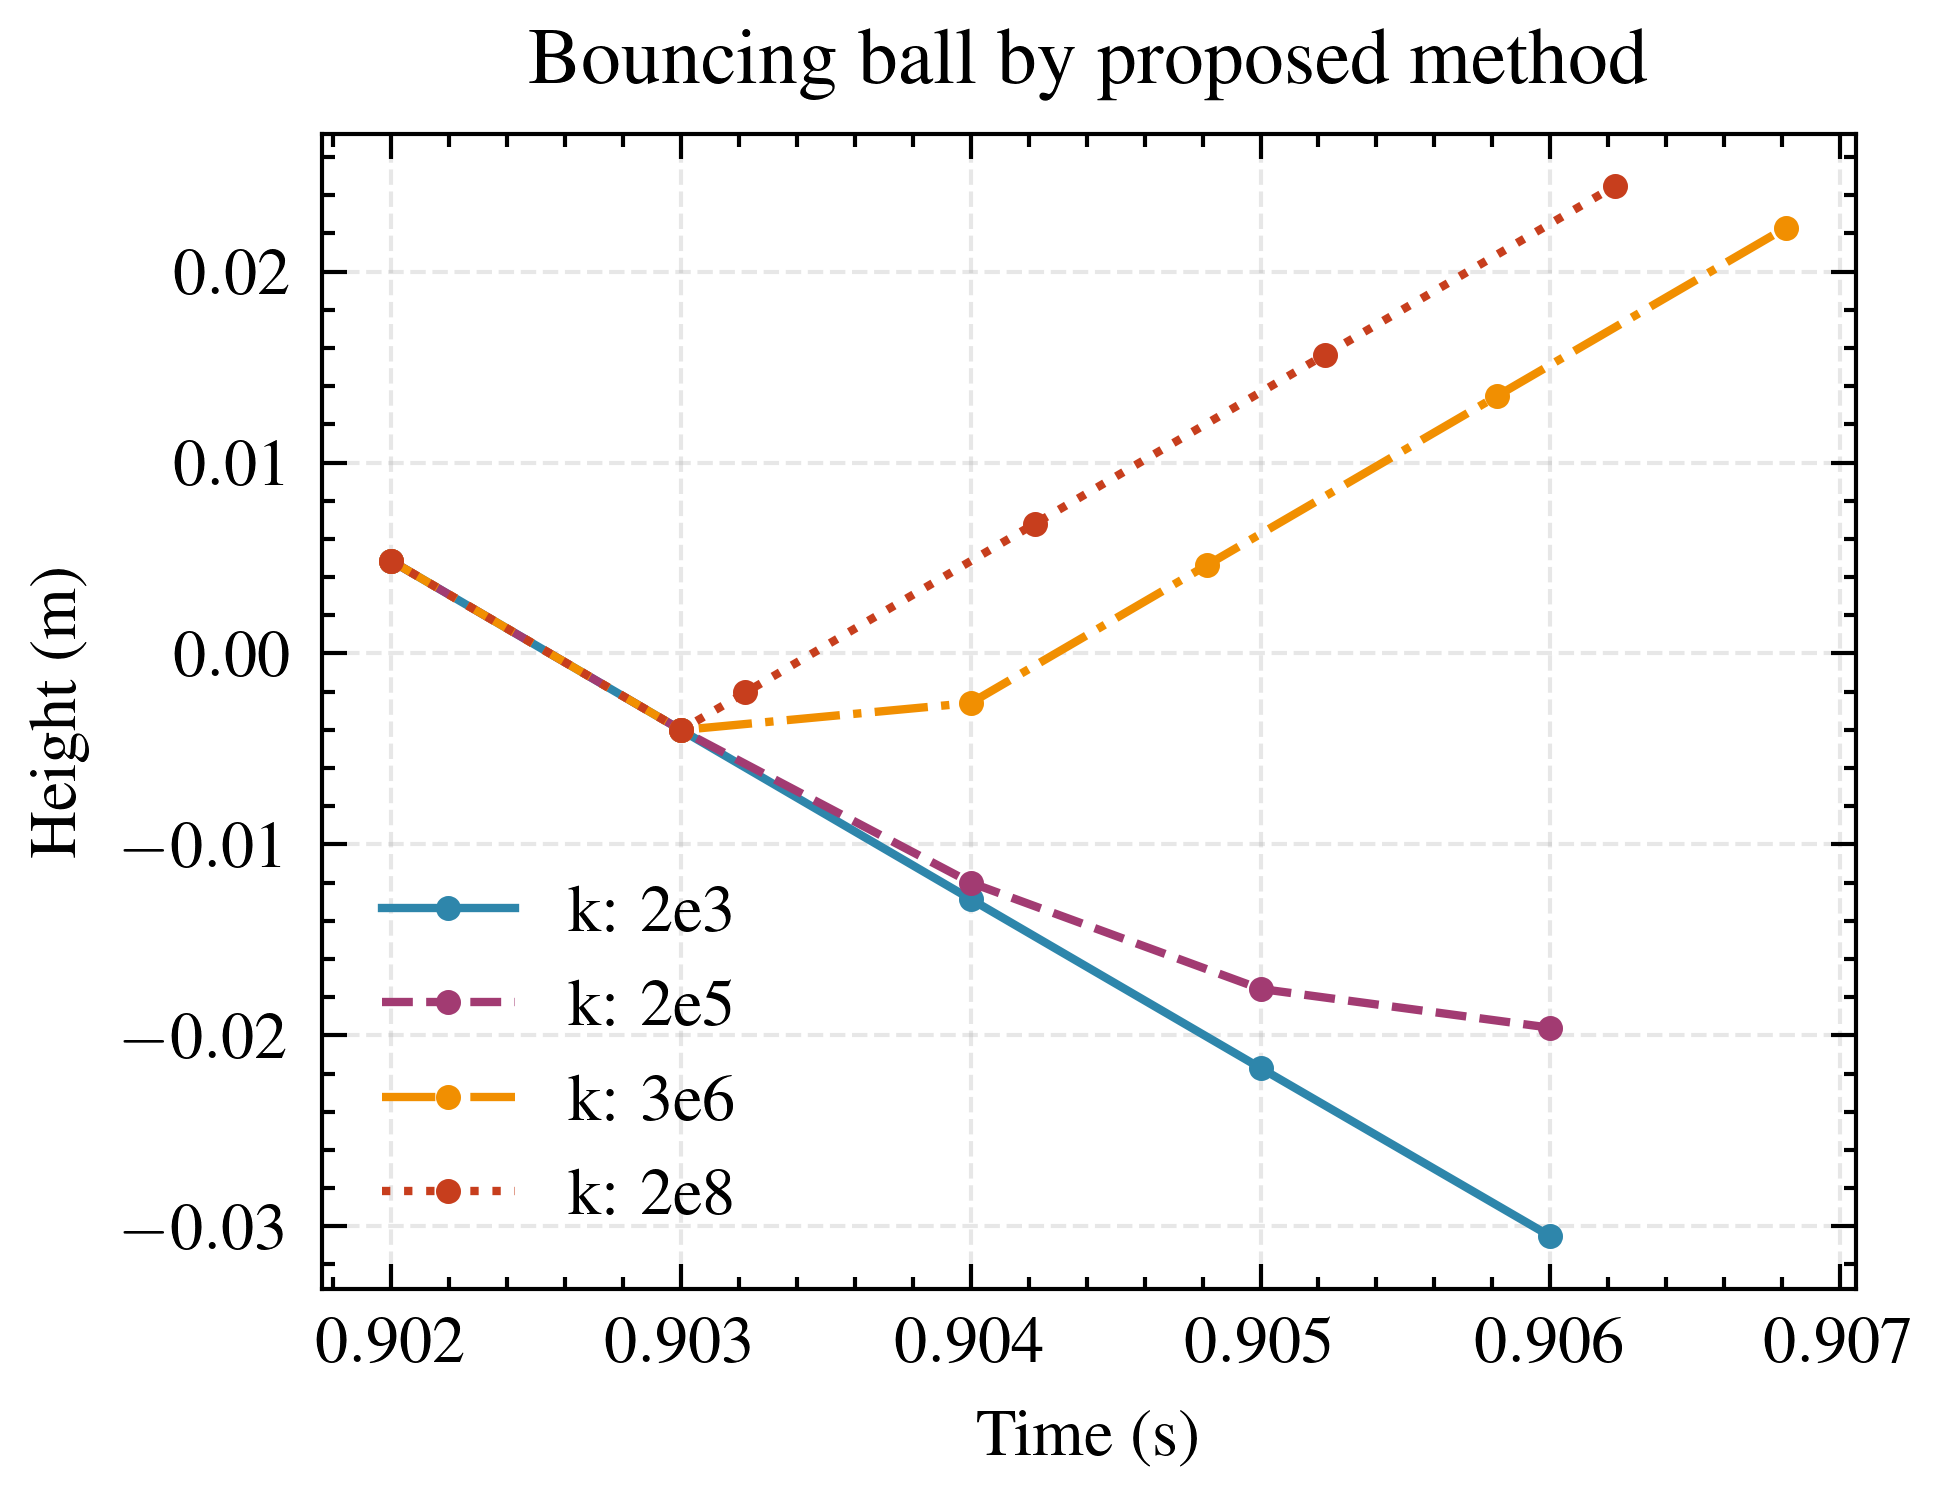

In [4]:
with plt.style.context(['science','ieee']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.906)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)')
  plt.xlabel(r'Time (s)')
  plt.title('Bouncing ball by proposed method')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [5]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 100]]
sim_duration = 4
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  result.append([displayInitJson, sim_result])


{k:2000.0,d:100,cof:0,threshold_velocity:1e-4}


902 961


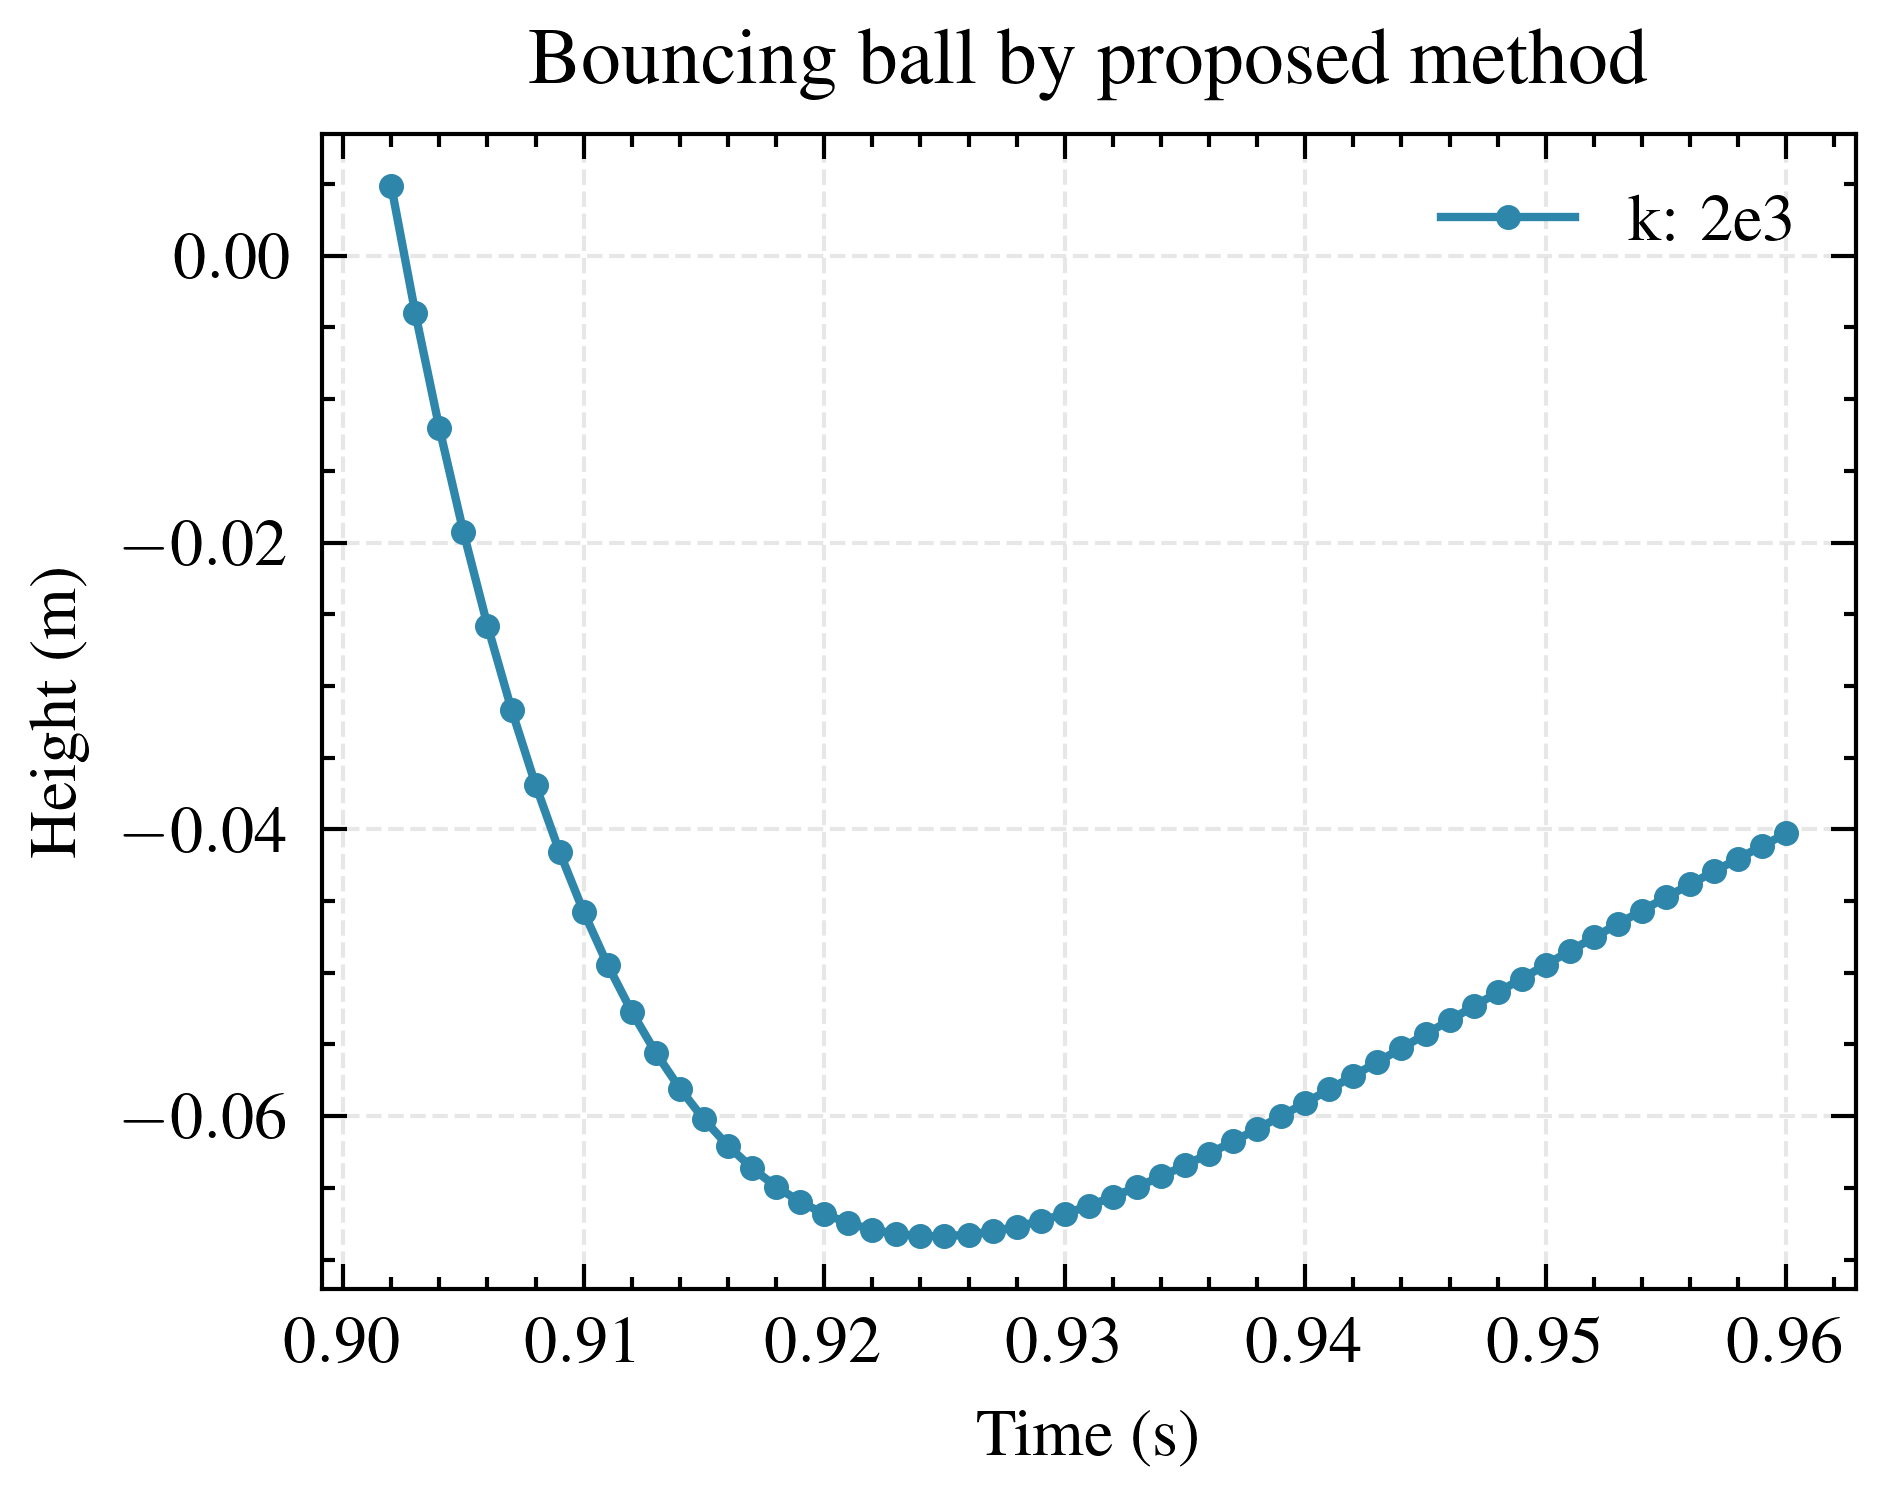

In [6]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')
with plt.style.context(['science','ieee']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.96)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)')
  plt.xlabel(r'Time (s)')
  plt.title('Bouncing ball by proposed method')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [7]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e6, 0], [3e6, 0]]
sim_duration = 2
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall2.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  pe.psVsSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  contact_solver_result = simulator.recordsContactCptInfo()
  result.append([displayInitJson, sim_result, contact_solver_result])


{k:2000000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:3000000.0,d:0,cof:0,threshold_velocity:1e-4}


{'currentTime': [0.9030000000000007, 0.9040000000000007, 0.9050000000000007], 'minTime': [0.002222548888566614, 0.0012207986275638426, 0.00023132309676786306], 'modifiedContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 0.0062913636681796135, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 1.3882681573670401}], [{'depth': 0.002054882813934934, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': -8.56513786815738}]], 'realContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'realDepth': 0.004010359999978175, 'velocity': 8.858429999999922}], [{'depth': 0.0013882681573670341, 'pair': {'id_A': 0, 'id_B': 1}, 'realDepth': 0.005398628157345209, 'velocity': 1.3882681573670403}], [{'depth': 0.001954882813934934, 'pair': {'id_A': 0, 'id_B': 1}, 'realDepth': 0.001954882813934934, 'velocity': -8.565137868157379}]]}
902 908
902 0.9020000000000007 0.0010000000000000009 [0.0, 0.0, 0.5048480700000217, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -8.8486199999

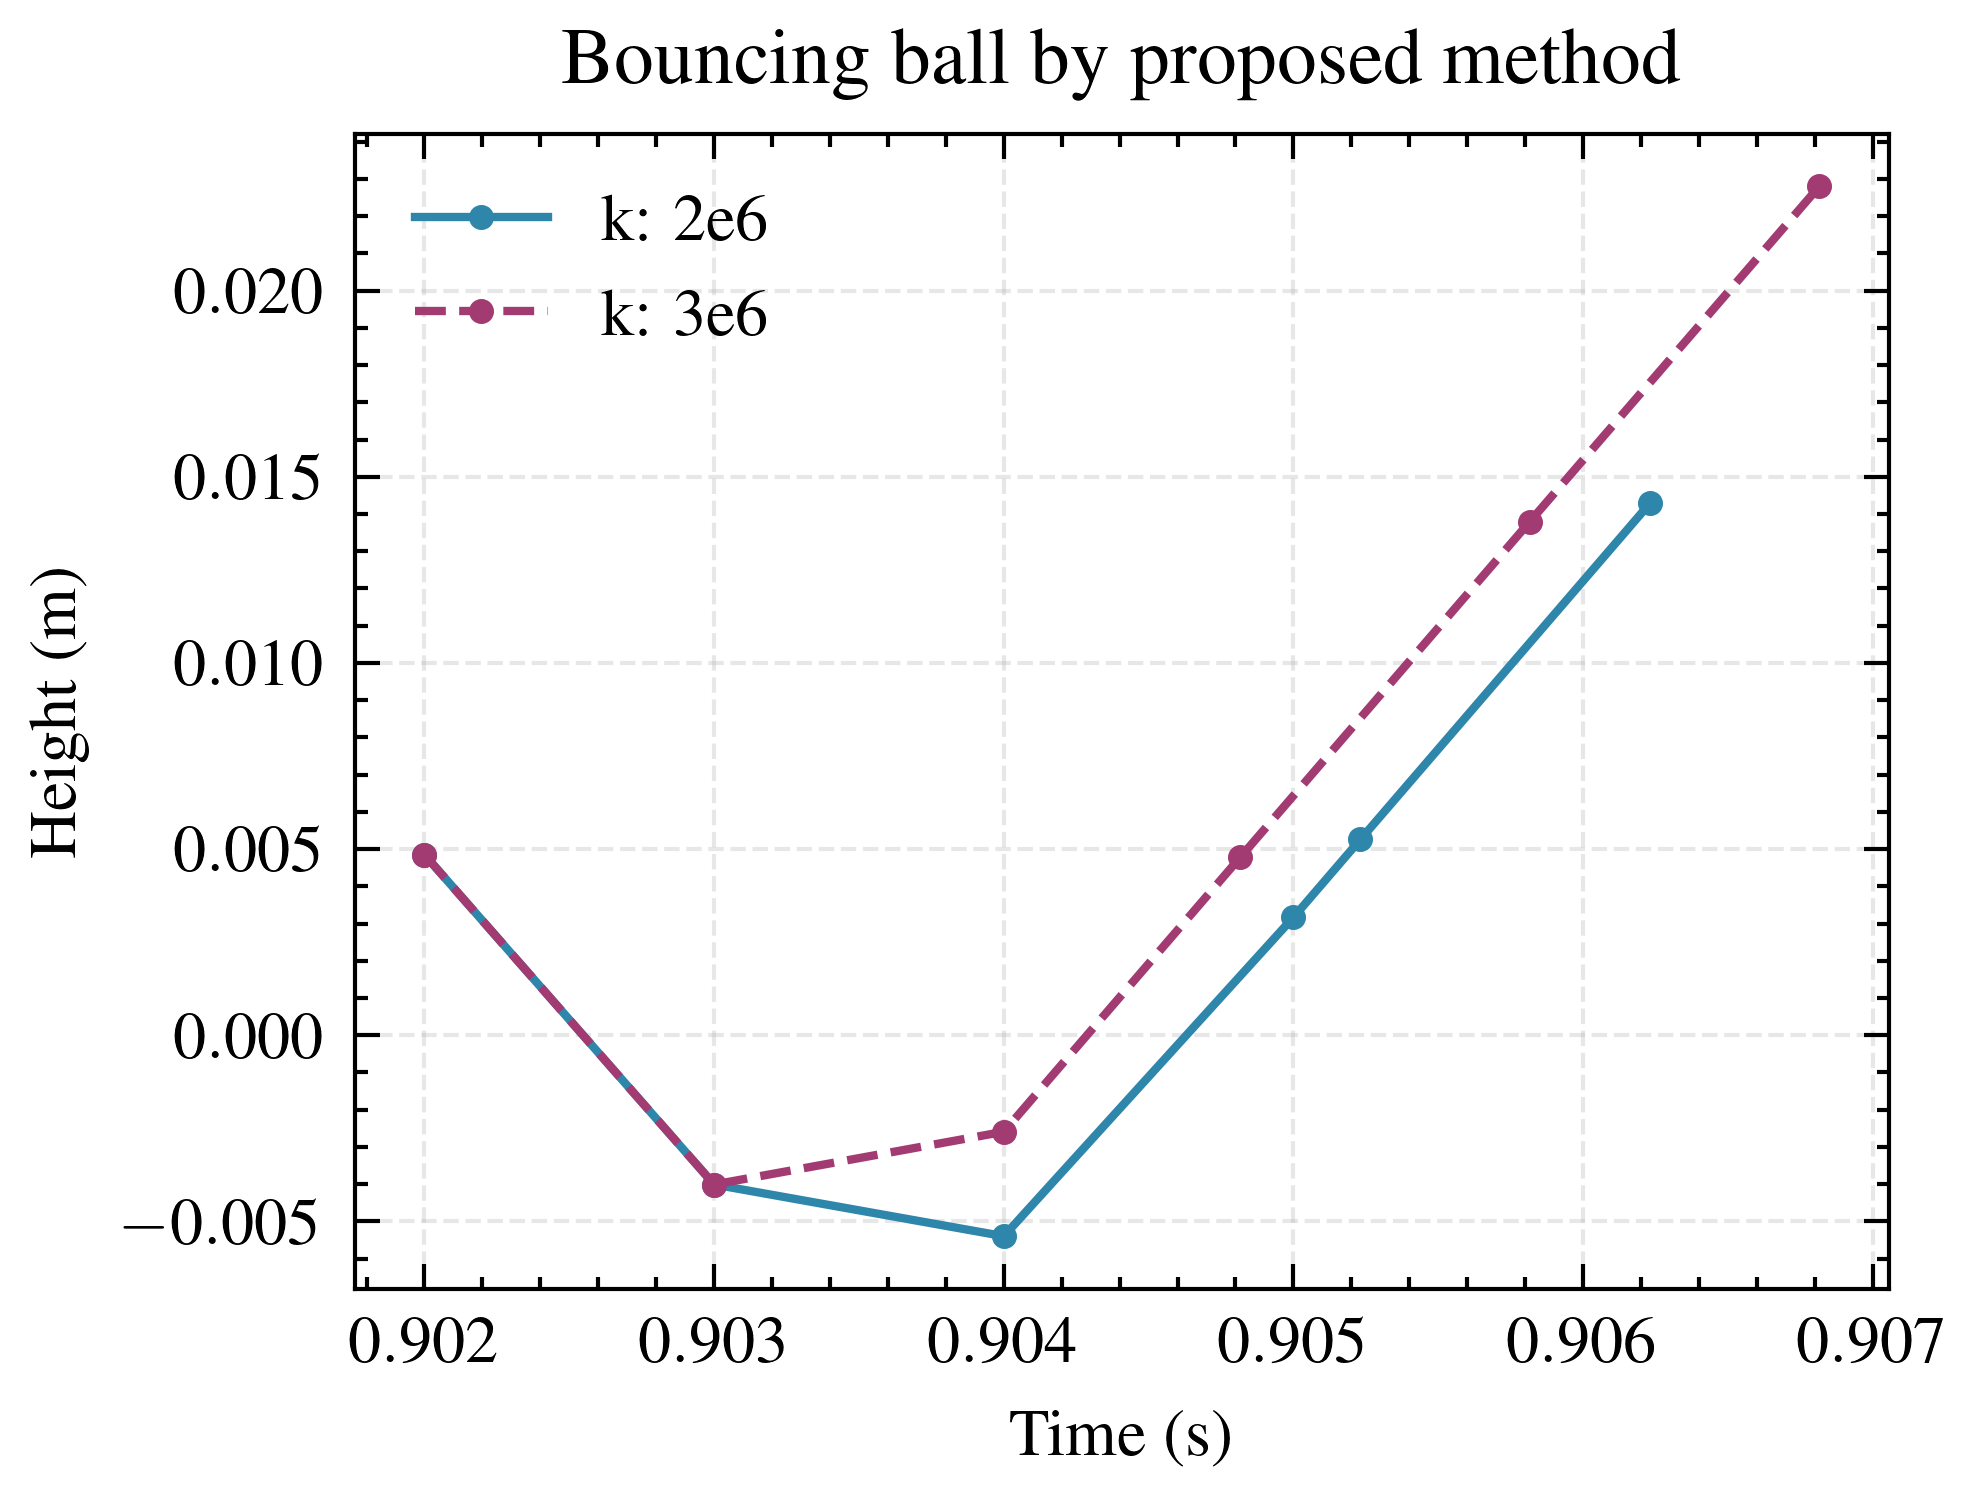

In [8]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')
with plt.style.context(['science','ieee']):
  legendStrs = []
  linestyles = ["-","--", "-.", ":"]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  for i in range(len(parameters)):
    pltResult = result[i][1]
    timeIndices = pltResult['timeIndex']
    contactInfo = pltResult["contactInfo"]
    partpq = pltResult["partPq"]
    partvs = pltResult["partVs"]
    partas = pltResult["partAs"]
    dts = pltResult["dts"]
    x = []
    y = []
    yv = []
    print(result[i][2])
    
    lowerBound = sire.binarySearch(timeIndices, 0.902)
    upperBound = sire.binarySearch(timeIndices, 0.906)
    print(lowerBound, upperBound + 1)
    
    for j in range(lowerBound, upperBound + 1):
      print(j, timeIndices[j], dts[j], partpq[j][1], partvs[j][1], partas[j][1], contactInfo[j])
      x.append(timeIndices[j])
      y.append(sire.pq2tfmatrix(partpq[j][1])[2, 3]-0.5)  # z position from transformation matrix
      yv.append(partvs[j][1][2])  # z velocity
    # .append(f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    # plt.plot(x, y, linewidth=1, label=f"k: {parameters[i][0]:.1e},d: {parameters[i][1]}")
    plt.plot(x, y, marker='o', markersize=2, linewidth=1, label=f"k: {simple_sci_format(parameters[i][0])}", color=scientific_colors[i], linestyle=linestyles[i% 4])
  
  plt.legend(loc="best", fontsize=8)
  plt.ylabel(r'Height (m)')
  plt.xlabel(r'Time (s)')
  plt.title('Bouncing ball by proposed method')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

In [6]:
print(contact_solver_result)

{'currentTime': [0.9030000000000007, 0.9040000000000007], 'minTime': [0.0018145376439472343, 0.0008145376439425468], 'modifiedContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 0.005051860818282451, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': -1.4166885304332149}]], 'realContactState': [[{'depth': 0.0, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': 8.858429999999922}], [{'depth': 1e-07, 'pair': {'id_A': 0, 'id_B': 1}, 'velocity': -1.4166885304332144}]]}


## Performance Tests

### Duration 10s simulation profile without dissipation.

In [7]:
# test simulation time
import sire
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 40
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
    cs.init()
    simulator = sire.simulationLoop(cs)
    pe = cs.physicsEngine()
    simulator.simDuration = sim_duration
    simulator.deltaT = dt
    simulator.ctrlT = ctrlt
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    start = time.perf_counter()
    while(not simulator.isTimeout()):
      simulator.step(1, False)
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_10s_zero_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

KeyboardInterrupt: 

In [ ]:
data = np.genfromtxt('sire_perf_measure_10s_zero_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.10162964 0.05951976 0.05422211 0.05691037]


### Duration 10s simulation profile with high dissipation.

In [ ]:
# test simulation time
import sire
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
parameters = [[2e3, 1e5], [2e5, 1e5], [3e6, 1e5], [2e8, 1e5]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 40
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
    cs.init()
    simulator = sire.simulationLoop(cs)
    pe = cs.physicsEngine()
    simulator.simDuration = sim_duration
    simulator.deltaT = dt
    simulator.ctrlT = ctrlt
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    start = time.perf_counter()
    while(not simulator.isTimeout()):
      simulator.step(1, False)
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_10s_high_dissipation.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

In [ ]:
data = np.genfromtxt('sire_perf_measure_10s_high_dissipation.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.35671691 0.36794823 0.44184616 0.46081957]


### Contact profile

In [ ]:
# test simulation time
import sire
import numpy as np
from os.path import abspath
import os
import time
cs = sire.ControlServer.instance()
timeCostResult = []
# parameters = [[2e3, 1e5], [2e5, 1e5], [3e6, 1e5], [2e8, 1e5]]
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 10
dt = 0.001
ctrlt = 100
n = 1000
timeCostResult = np.zeros([len(parameters), n])

for i in range(len(parameters)):
  # timeCost = 0
  for j in range(n):
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/profile_contact.xml")
    cs.init()
    simulator = sire.simulationLoop(cs)
    pe = cs.physicsEngine()
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    # print(contactPropStr)
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    isCtrl = simulator.integrate()
    start = time.perf_counter()
    simulator.handleContact()
    end = time.perf_counter()
    elapsed = end - start
    timeCostResult[i][j] = elapsed
    # timeCost += elapsed
  # timeCostResult.append(timeCost)

# Save time cost data csv
np.savetxt(
    'sire_perf_measure_contact.csv',          # Filename
    timeCostResult.transpose(),  # Combine x and y into two columns
    delimiter=',',            # Use comma as delimiter
    comments=''               # Remove '#' from header
)

In [ ]:
data = np.genfromtxt('sire_perf_measure_contact.csv', delimiter=',')

print(np.sum(data, 0) / data.shape[0])

[0.00015384 0.00017942 0.00019874 0.00019157]


## Parameter k Range Tests

In [ ]:
import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
start = 200
end = 2e45
num_points = 1000  # 你需要的点数

# 最简单的方法
parameters = np.geomspace(start, end, num_points)
# parameters = [[2e2, 0], [2e30, 0]]
sim_duration = 2.2
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i]},d:0,cof:0,threshold_velocity:1e-4}}"
  # print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  # displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  # contact_solver_result = simulator.recordsContactCptInfo()
  result.append(sim_result)

heights = np.zeros(np.size(parameters))
for i in range(len(parameters)):
  pltResult = result[i]
  timeIndices = pltResult['timeIndex']
  partpq = pltResult["partPq"]
  
  lowerBound = 900
  upperBound = sire.binarySearch(timeIndices, 2.2)
  firstBounceHeight = 0
  for j in range(900, upperBound + 1):
    # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
    height = partpq[j][1][2]-0.5
    if height > firstBounceHeight:
       firstBounceHeight = height
  heights[i] = firstBounceHeight - 4

if len(heights) == len(parameters):
  # Save first bouncing height data csv
  np.savetxt(
      'first_bouncing_data.csv',          # Filename
      np.column_stack((parameters, heights)),  # Combine x and y into two columns
      delimiter=',',            # Use comma as delimiter
      header='stiffness,height',             # Column headers
      comments=''               # Remove '#' from header
  )

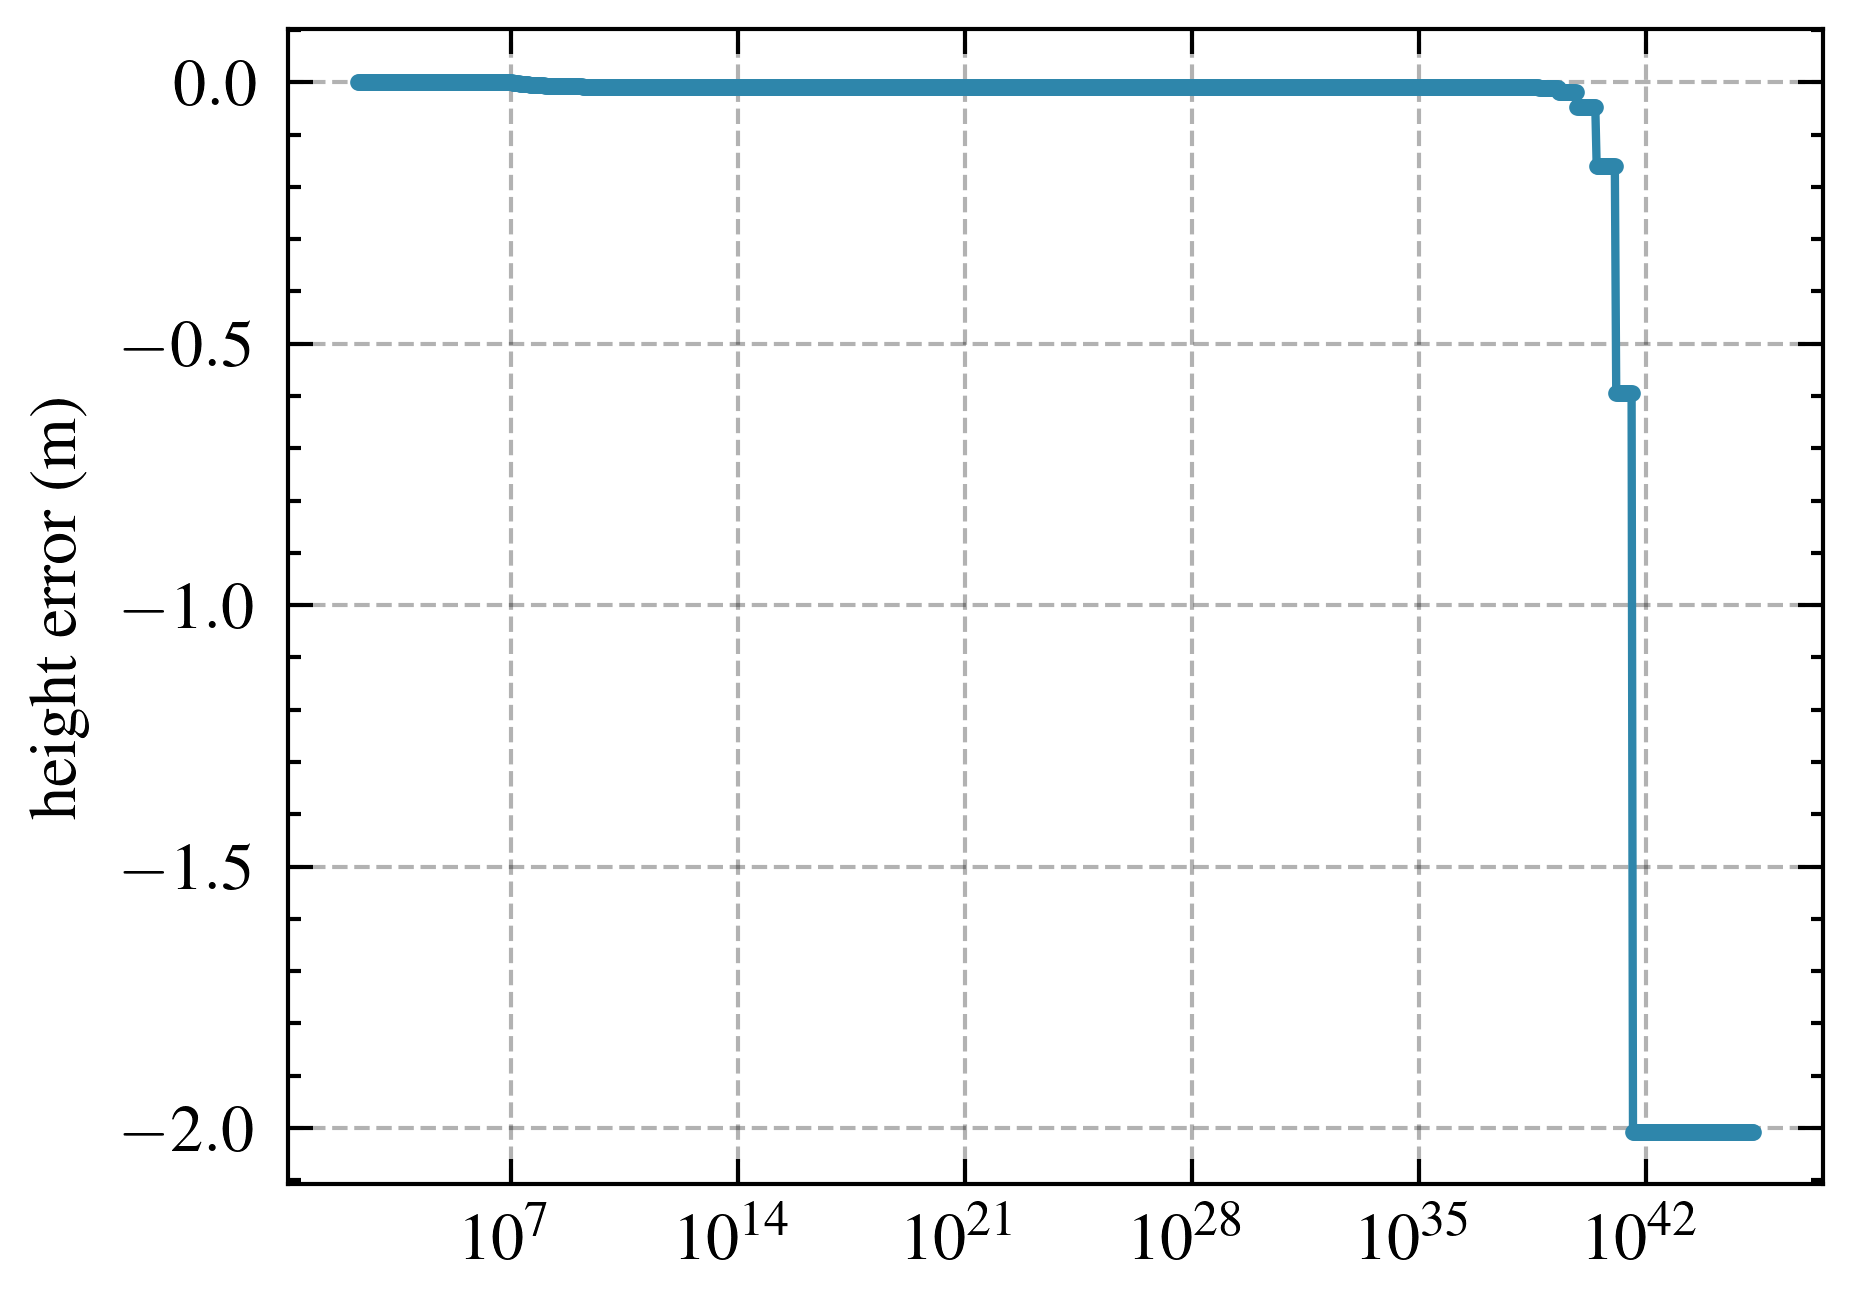

In [ ]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

def simple_sci_format(number):
    """最简单的科学计数法格式化"""
    sci_str = f"{number:.0e}"
    return sci_str.replace('+0', '').replace('+', '')

with plt.style.context(['science','ieee', 'grid']):
  legendStrs = []
  linestyles = ["-", ":", "--", "-."]
  scientific_colors = [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#6B8E23', '#8B4513', '#4682B4', '#D2691E', '#2F4F4F'
  ]
  plt.semilogx(parameters, heights, marker='o', markersize=1, linewidth=1, color=scientific_colors[0])
  # plt.legend(loc="best", fontsize=8)
  # plt.legend(framealpha=0.9, loc="upper right")
  # plt.ylim(top=5.5, bottom=-0.5)
  plt.ylabel(r'height error (m)')
  plt.grid(True, linestyle='--', alpha=0.3)
  # plt.xlabel(r'Time (s)')
  # plt.title('Bouncing ball by proposed method')
  # plt.grid(True, alpha=0.3)
  # plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data_sire.pdf", format="pdf")
  plt.show()

## Snapshots

In [ ]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import TimeoutException
from selenium import webdriver
import base64
import io
from PIL import Image
import meshcat
import numpy as np

import sire
from os.path import abspath
import os
cs = sire.ControlServer.instance()
result = []
parameters = [[2e3, 0], [2e5, 0], [3e6, 0], [2e8, 0]]
sim_duration = 4
dt = 0.001
ctrlt = 10

for i in range(len(parameters)):
  sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
  cs.init()
  simulator = sire.simulationLoop(cs)
  pe = cs.physicsEngine()
  simulator.simDuration = sim_duration
  simulator.deltaT = dt
  simulator.ctrlT = ctrlt
  contactPropStr = f"{{k:{parameters[i][0]},d:0,cof:0,threshold_velocity:1e-4}}"
  print(contactPropStr)
  # print(contactPropStr)
  pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
  while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
    simulator.step(1, False)
  model = cs.model()
  displayInitJson = model.displayInitJson()
  sim_result = simulator.recordsToJson()
  # contact_solver_result = simulator.recordsContactCptInfo()
  result.append([sim_result, displayInitJson])

vis = meshcat.Visualizer()
heights = np.zeros(np.size(parameters))
for i in range(len(parameters)):
  pltResult = result[i][0]
  timeIndices = pltResult['timeIndex']
  partpq = pltResult["partPq"]
  resourcePath = "D:/code/sire/demo/demo_python/dogRL"
  sire.robotInit(model.numLinks(), resourcePath, result[i][1], vis)
  lowerBound = 900
  upperBound = sire.binarySearch(timeIndices, 2.2)
  firstBounceHeight = 0
  for j in range(900, upperBound + 1):
    # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
    heights[i] = partpq[j][1][2]-0.5
    if heights[i] > firstBounceHeight:
      firstBounceHeight = heights[i]
      maxIndex = j
  heights[i] = firstBounceHeight - 4
  sire.setRobotPq(model.numLinks(), vis, partpq[maxIndex])
  print(maxIndex, firstBounceHeight, partpq[maxIndex][1][2])
  # vis.set_cam_pos([5, 0, 6])
  # vis.set_cam_target([10, 0, 10])
  
  vis["/Cameras/default"].set_transform(np.eye(4))
  vis["/Cameras/default/rotated/<object>"].set_property("fov", 20) # 默认通常是 50 或 75，改小如 30 或 20
  # 或者使用 zoom
  # vis["/Cameras/default/rotated/<object>"].set_property("zoom", 2.0)
  vis.set_cam_pos([30, 0, 0])
  # vis.set_cam_target([0.5, 1., -0.5])
  # img = vis.get_image()
  # cropped_img = img.crop((1000, 0, 1500, 800))
  # cropped_img
  # Set up Chrome options to run in headless mode
  print("Capturing image from Meshcat viewer...")
  chrome_options = webdriver.ChromeOptions()
  chrome_options.add_argument('--headless')
  chrome_options.add_argument("--window-size=1920,1080")
  # chrome_options.add_argument('--no-sandbox')
  # chrome_options.add_argument('--disable-dev-shm-usage')

  # Initialize the Chrome WebDriver 
  service = Service(executable_path=r"c:\chromedriver\chromedriver.exe")
  driver = webdriver.Chrome(service=service, options=chrome_options)

  # Open the Meshcat viewer's URL
  driver.set_page_load_timeout(10)  # 10 秒超时
  # try:
  driver.get(vis.url())
  # except TimeoutException:
  #     print("页面加载超时，但继续执行")
      # 等待 viewer 对象存在（最多等待 10 秒）
  wait = WebDriverWait(driver, 10)
  wait.until(lambda d: d.execute_script("return typeof viewer !== 'undefined' && viewer.capture_image !== undefined"))

  # 如果 capture_image 返回 Promise，使用 execute_async_script
  # image_data_url = driver.execute_async_script("""
  #     var callback = arguments[arguments.length - 1];
  #     viewer.capture_image(200, 100).then(function(dataUrl) {
  #         callback(dataUrl);
  #     }).catch(function(err) {
  #         callback(null);
  #     });
  # """)
  image_data_url = driver.execute_script("""
      return viewer.capture_image(200, 100);  // Capture the image with width and height
  """)
  # Extract the base64 part of the data URL (after "data:image/png;base64,")
  image_base64 = image_data_url.split(",")[1]
  print("Image captured, processing...")

  # Decode the base64 string and save it as an image file
  image_data = base64.b64decode(image_base64)
  # Write the image to a file
  image = Image.open(io.BytesIO(image_data))
  print(image._size)
  cropped_img = image.crop((700, 0, 1200, 600))

  # cropped_img = image.crop((700, 0, 1200, 800))
  cropped_img.save(f"./pic/{parameters[i][0]}.png")
  # with open(f"./test_data/{parameters[i][0]}.png", "wb+") as f:
  #     f.write(image_data)

  # Close the browser session
  driver.quit()

{k:2000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:3000000.0,d:0,cof:0,threshold_velocity:1e-4}
{k:200000000.0,d:0,cof:0,threshold_velocity:1e-4}
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/
1877 4.000001221504022 4.500001221504022
Capturing image from Meshcat viewer...
Image captured, processing...
(1902, 932)
1813 4.000004929162559 4.500004929162559
Capturing image from Meshcat viewer...
Image captured, processing...
(1902, 932)
1808 3.9997737832315954 4.499773783231595
Capturing image from Meshcat viewer...
Image captured, processing...
(1902, 932)
1807 3.9931095164752257 4.493109516475226
Capturing image from Meshcat viewer...
Image captured, processing...
(1902, 932)


Testing with stiffness 2000.0 and damping 0.1
力  9.0 N -> 最大高度 0.000 m
力  9.1 N -> 最大高度 0.000 m
力  9.2 N -> 最大高度 0.000 m
力  9.3 N -> 最大高度 0.000 m
力  9.4 N -> 最大高度 0.000 m
力  9.5 N -> 最大高度 0.000 m
力  9.6 N -> 最大高度 0.000 m
力  9.7 N -> 最大高度 0.000 m
力  9.8 N -> 最大高度 0.000 m
力  9.9 N -> 最大高度 0.007 m
力 10.0 N -> 最大高度 0.015 m
力 10.1 N -> 最大高度 0.024 m
力 10.2 N -> 最大高度 0.032 m
力 10.3 N -> 最大高度 0.041 m
力 10.4 N -> 最大高度 0.050 m
力 10.5 N -> 最大高度 0.059 m
力 10.6 N -> 最大高度 0.068 m
力 10.7 N -> 最大高度 0.078 m
力 10.8 N -> 最大高度 0.087 m
力 10.9 N -> 最大高度 0.097 m
力 11.0 N -> 最大高度 0.107 m
力 11.1 N -> 最大高度 0.117 m
力 11.2 N -> 最大高度 0.127 m
力 11.3 N -> 最大高度 0.137 m
力 11.4 N -> 最大高度 0.148 m
力 11.5 N -> 最大高度 0.158 m
力 11.6 N -> 最大高度 0.169 m
力 11.7 N -> 最大高度 0.180 m
力 11.8 N -> 最大高度 0.191 m
力 11.9 N -> 最大高度 0.203 m
力 12.0 N -> 最大高度 0.214 m
Testing with stiffness 200000.0 and damping 0.1
力  9.0 N -> 最大高度 0.000 m
力  9.1 N -> 最大高度 0.000 m
力  9.2 N -> 最大高度 0.000 m
力  9.3 N -> 最大高度 0.000 m
力  9.4 N -> 最大高度 0.000 m
力  9.5

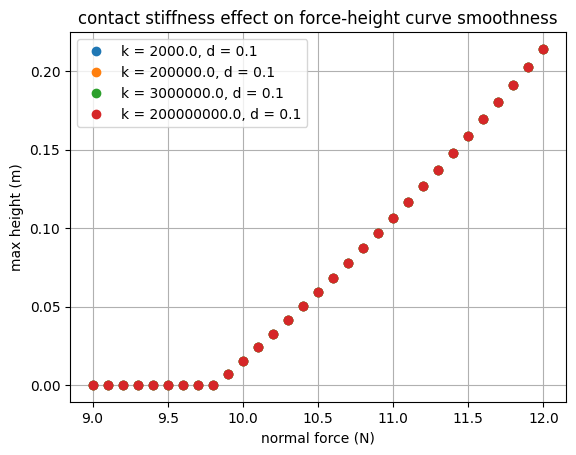

In [9]:
import sire
from os.path import abspath
import numpy as np
import os
import matplotlib.pyplot as plt

cs = sire.ControlServer.instance()
parameters = [[2e3, 0.1], [2e5, 0.1], [3e6, 0.1], [2e8, 0.1]]
sim_duration = 1
force_duration = 0.4
dt = 0.001
ctrlt = 10

force_range = np.linspace(9, 12, 31)  # 9~12 N，31个点

heights = np.zeros([len(parameters), len(force_range)])
for i in range(len(parameters)):
  print(f"Testing with stiffness {parameters[i][0]} and damping {parameters[i][1]}")
  for k in range(len(force_range)):
    f = force_range[k]
    sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_with_up_force.xml")
    cs.init()
    simulator = sire.simulationLoop(cs)
    pe = cs.physicsEngine()
    simulator.simDuration = sim_duration
    simulator.deltaT = dt
    simulator.ctrlT = ctrlt
    contactPropStr = f"{{k:{parameters[i][0]},d:{parameters[i][1]},cof:0,threshold_velocity:1e-4}}"
    pe.contactPositionForceSolver().addMaterialPair("steel", "copper", contactPropStr)
    # print(sire.toXmlString(cs))
    while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
      isCtrl = simulator.integrate()
      model = cs.model()
      if simulator.simTime() <= force_duration:
        if isinstance(model.forcePool()[0], sire.GeneralForce):
          model.forcePool()[0].fce = [0, 0, f, 0, 0, 0]
      else:
        if isinstance(model.forcePool()[0], sire.GeneralForce):
          model.forcePool()[0].fce = [0, 0, 0, 0, 0, 0]
      simulator.handleContact()
      # simulator.step(1, False)
    displayInitJson = model.displayInitJson()
    sim_result = simulator.recordsToJson()
    time_force_end = force_duration
    timeIndices = sim_result['timeIndex']
    contactInfo = sim_result["contactInfo"]
    partpq = sim_result["partPq"]
    max_height = -1  # 初始高度
    for j in range(len(timeIndices)-1):
      # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
      # print(f"{j}: time: {timeIndices[j]}")
      # print(f"Current ps: {partpq[j][0]}")
      current_height = partpq[j][1][2] - 0.2  # z position from transformation matrix
      if current_height > max_height:
        max_height = current_height

    # for step in range(int(sim_time / dt)):
    #     t = step * dt
    #     if t < time_force_end:
    #         # 在球心施加向上的力
    #         p.applyExternalForce(sphere_id, -1, forceObj=[0, 0, force],
    #                              posObj=[0, 0, 0.2], flags=p.LINK_FRAME)
    #     p.stepSimulation()
    #     pos, _ = p.getBasePositionAndOrientation(sphere_id)
    #     current_height = pos[2] - radius  # 球心高度减去半径得到球底高度
    #     if current_height > max_height:
    #         max_height = current_height
    
    # h = run_simulation(f, stiffness_high, damping_high, force_duration=0.4)
    heights[i, k] = max_height
    print(f"力 {f:4.1f} N -> 最大高度 {max_height:.3f} m")

# -------------------- 绘制结果 --------------------
for i in range(len(parameters)):
  plt.plot(force_range, heights[i], 'o', label=f'k = {parameters[i][0]}, d = {parameters[i][1]}')
plt.xlabel('normal force (N)')
plt.ylabel('max height (m)')
# plt.title('接触刚度对推力-高度曲线平滑性的影响')
plt.title('contact stiffness effect on force-height curve smoothness')
plt.legend()
plt.grid(True)
plt.show()

测试高刚度接触...
力  9.1 N -> slope 0.00000 m
力  9.1 N -> slope 0.00000 m
力  9.2 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 m
力  9.6 N -> slope 0.00000 m
力  9.6 N -> slope 0.00000 m
力  9.8 N -> slope 0.00000 m
力  9.9 N -> slope 0.07267 m
力  9.9 N -> slope 0.08228 m
力 10.1 N -> slope 0.08391 m
力 10.1 N -> slope 0.08554 m
力 10.2 N -> slope 0.08717 m
力 10.4 N -> slope 0.08881 m
力 10.4 N -> slope 0.09044 m
力 10.6 N -> slope 0.09207 m
力 10.6 N -> slope 0.09370 m
力 10.8 N -> slope 0.09533 m
力 10.9 N -> slope 0.09696 m
力 10.9 N -> slope 0.09859 m
力 11.1 N -> slope 0.10022 m
力 11.1 N -> slope 0.10185 m
力 11.2 N -> slope 0.10348 m
力 11.4 N -> slope 0.10511 m
力 11.4 N -> slope 0.10675 m
力 11.6 N -> slope 0.10838 m
力 11.6 N -> slope 0.11001 m
力 11.8 N -> slope 0.11164 m
力 11.9 N -> slope 0.11327 m
力 11.9 N -> slope 0.11491 m
测试低刚度接触...
力  9.1 N -> slope 0.00000 m
力  9.1 N -> slope 0.00000 m
力  9.2 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 m
力  9.4 N -> slope 0.00000 

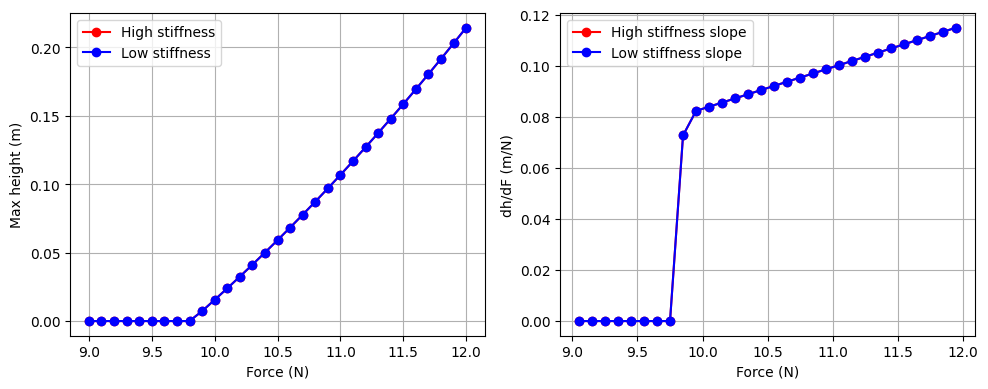

In [10]:
# 计算一阶差分近似导数
diff_high = np.diff(heights[3]) / np.diff(force_range)
diff_low  = np.diff(heights[0])  / np.diff(force_range)
force_mid = (force_range[:-1] + force_range[1:]) / 2

# 高刚度测试
print("测试高刚度接触...")
for i in range(len(force_mid)):
    print(f"力 {force_mid[i]:4.1f} N -> slope {diff_high[i]:.5f} m")

# 低刚度测试
print("测试低刚度接触...")
for i in range(len(force_mid)):
    print(f"力 {force_mid[i]:4.1f} N -> slope {diff_low[i]:.5f} m")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(force_range, heights[3], 'r-o', label='High stiffness')
plt.plot(force_range, heights[0],  'b-o', label='Low stiffness')
plt.xlabel('Force (N)'); plt.ylabel('Max height (m)')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(force_mid, diff_high, 'r-o', label='High stiffness slope')
plt.plot(force_mid, diff_low,  'b-o', label='Low stiffness slope')
plt.xlabel('Force (N)'); plt.ylabel('dh/dF (m/N)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()